# 02. Modeling

## 目的

このNotebookでは、Telco Customer Churnデータセットを用いて、顧客解約を予測する機械学習モデルを構築する。

主な流れは以下である。

- データ前処理
- 学習データとテストデータの分割
- 複数モデルの比較
- 評価指標による性能確認
- 最終モデルの保存

## ライブラリ読み込み

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

## 1. データ読み込み

In [11]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [13]:
df = df.drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


## 2. 特徴量と目的変数に分ける

In [15]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

## 3. 数値変数・カテゴリ変数を分ける

In [16]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

## 4. Preprocessing Pipeline

数値変数には標準化を行い、カテゴリ変数にはOne-Hot Encodingを適用する。
これらの前処理を `ColumnTransformer` を使ってまとめる。

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## 5. Train/Test Split

モデルの汎化性能を確認するため、データを学習用とテスト用に分割する。

目的変数 `Churn` には偏りがあるため、`stratify=y` を指定して、学習データとテストデータでクラス比率が大きく変わらないようにする。

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

In [22]:
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [21]:
y_train.value_counts(normalize=True)

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

## 6. Evaluation Function

複数のモデルを比較するため、Accuracy, Precision, Recall, F1-score, ROC-AUC をまとめて計算する関数を作成する。

In [24]:
def evaluate_model(model_name, pipeline, X_test, y_test):
    """
    Evaluate a trained model and return metrics.
    """
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

    return metrics

## 7. Model Training

以下の3つのモデルを学習し、性能を比較する。

- Logistic Regression
- Random Forest
- Gradient Boosting

まずは複雑なチューニングは行わず、基本的な設定で比較する。

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [29]:
results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    metrics = evaluate_model(model_name, pipeline, X_test, y_test)
    results.append(metrics)

    trained_pipelines[model_name] = pipeline

In [30]:
results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
1,Random Forest,0.786373,0.625430,0.486631,0.547368,0.818510
2,Gradient Boosting,0.802697,0.665517,0.516043,0.581325,0.843275


In [31]:
results_df.sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
2,Gradient Boosting,0.802697,0.665517,0.516043,0.581325,0.843275
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
1,Random Forest,0.786373,0.625430,0.486631,0.547368,0.818510


## 8. Model Comparison

各モデルの評価指標を比較する。
解約予測では、単純なAccuracyだけでなく、解約顧客をどれだけ検出できるかを示すRecallや、分類性能全体を示すROC-AUCも重視する。

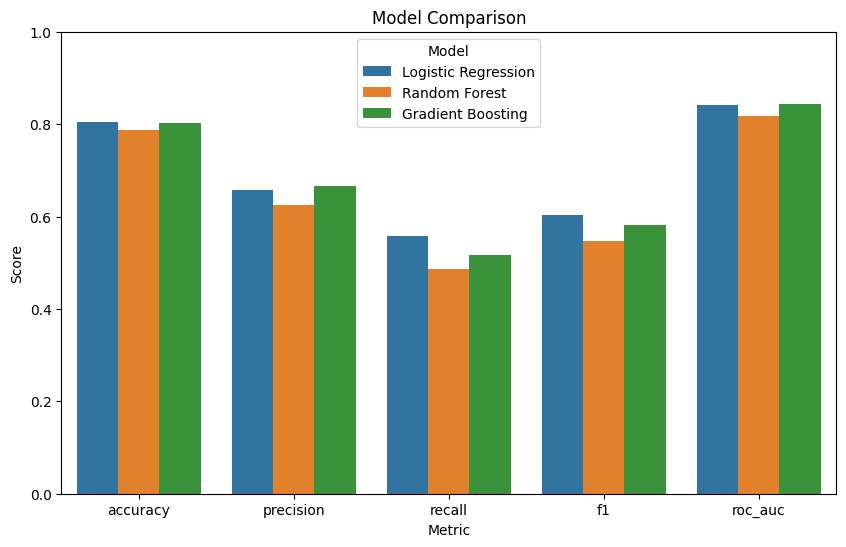

In [33]:
results_melted = results_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x="metric", y="score", hue="model")
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model")
plt.show()

## 9. Select Best Model

ROC-AUCが最も高いモデルを最終モデルとして選択する。
ROC-AUCは、閾値に依存せずモデルの分類性能を評価できるため、解約予測のような二値分類問題で参考になる。

In [34]:
best_model_name = results_df.sort_values("roc_auc", ascending=False).iloc[0]["model"]
best_model_name

'Gradient Boosting'

In [35]:
best_model = trained_pipelines[best_model_name]
best_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 10. Final Model Evaluation

選択した最終モデルについて、Classification ReportとConfusion

In [36]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [38]:
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.8432754656539823


In [39]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[938,  97],
       [181, 193]])

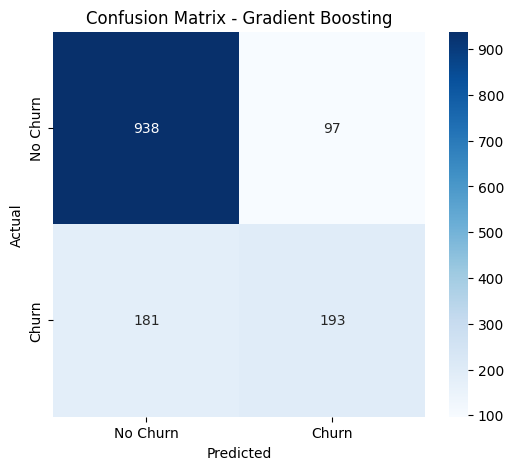

In [40]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix の見方

- 左上：解約しない顧客を正しく「解約しない」と予測した数
- 右上：解約しない顧客を誤って「解約する」と予測した数
- 左下：解約する顧客を誤って「解約しない」と予測した数
- 右下：解約する顧客を正しく「解約する」と予測した数

解約予測では、実際に解約する顧客を見逃すことが問題になるため、左下の件数を減らすことが重要である。

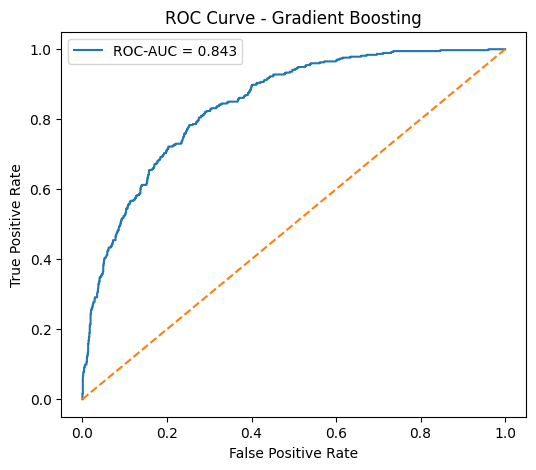

In [43]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 11. Feature Importance

最終モデルがRandom ForestまたはGradient Boostingの場合、特徴量重要度を確認する。
カテゴリ変数はOne-Hot Encoding後の特徴量名を取得して可視化する。

In [44]:
final_estimator = best_model.named_steps["model"]

In [45]:
if hasattr(final_estimator, "feature_importances_"):
    # 数値特徴量名
    num_feature_names = numeric_features

    # One-Hot Encoding後のカテゴリ特徴量名
    cat_encoder = best_model.named_steps["preprocessor"].named_transformers_["cat"]
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

    # 全特徴量名
    feature_names = np.concatenate([num_feature_names, cat_feature_names])

    # 重要度
    importances = final_estimator.feature_importances_

    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    feature_importance_df.head(20)
else:
    print(f"{best_model_name} does not have feature_importances_.")

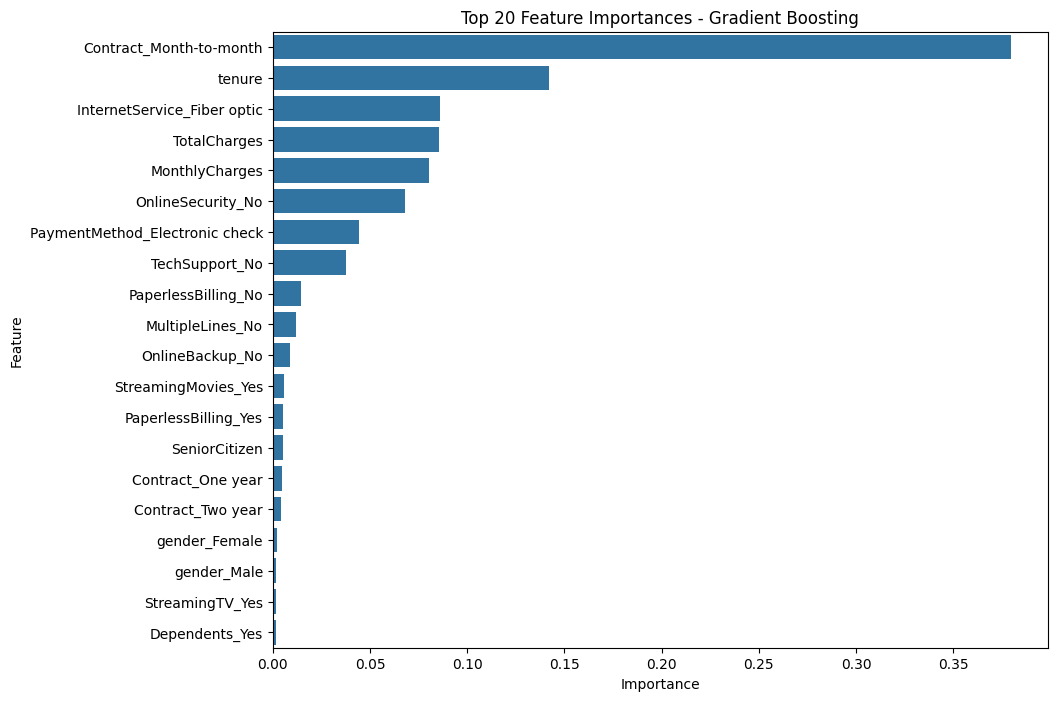

In [46]:
if hasattr(final_estimator, "feature_importances_"):
    top_features = feature_importance_df.head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=top_features, x="importance", y="feature")
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

## 12. Save Model

最終モデルを保存する。
保存したモデルは、後でStreamlitアプリから読み込んで予測に使用する。

In [48]:
joblib.dump(best_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']

In [49]:
print(f"Saved model: {best_model_name}")


Saved model: Gradient Boosting


In [50]:
results_df.to_csv("../reports/model_results.csv", index=False)
print("Saved model results to ../reports/model_results.csv")

Saved model results to ../reports/model_results.csv


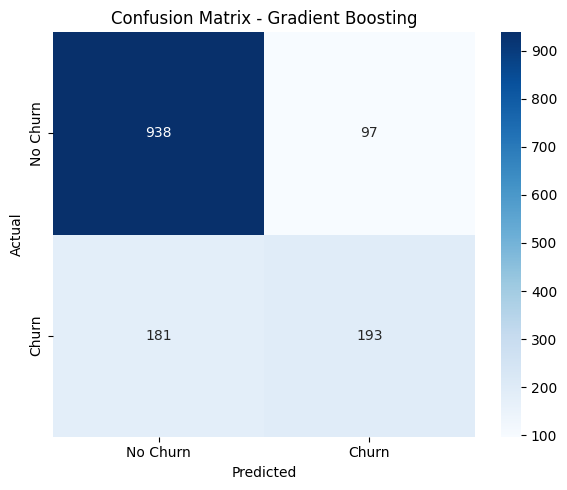

In [51]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix.png", dpi=300)
plt.show()

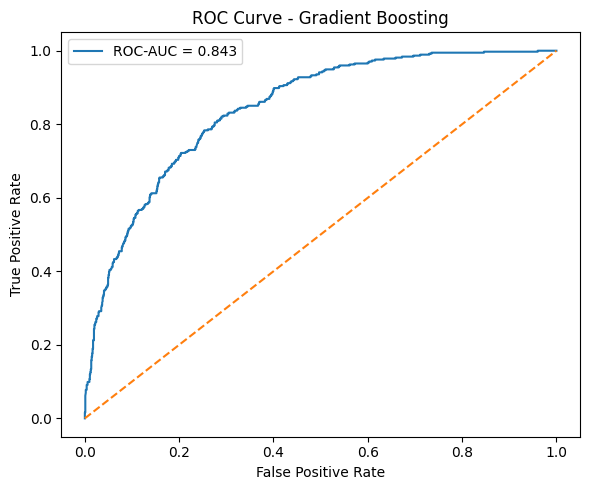

In [52]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/roc_curve.png", dpi=300)
plt.show()

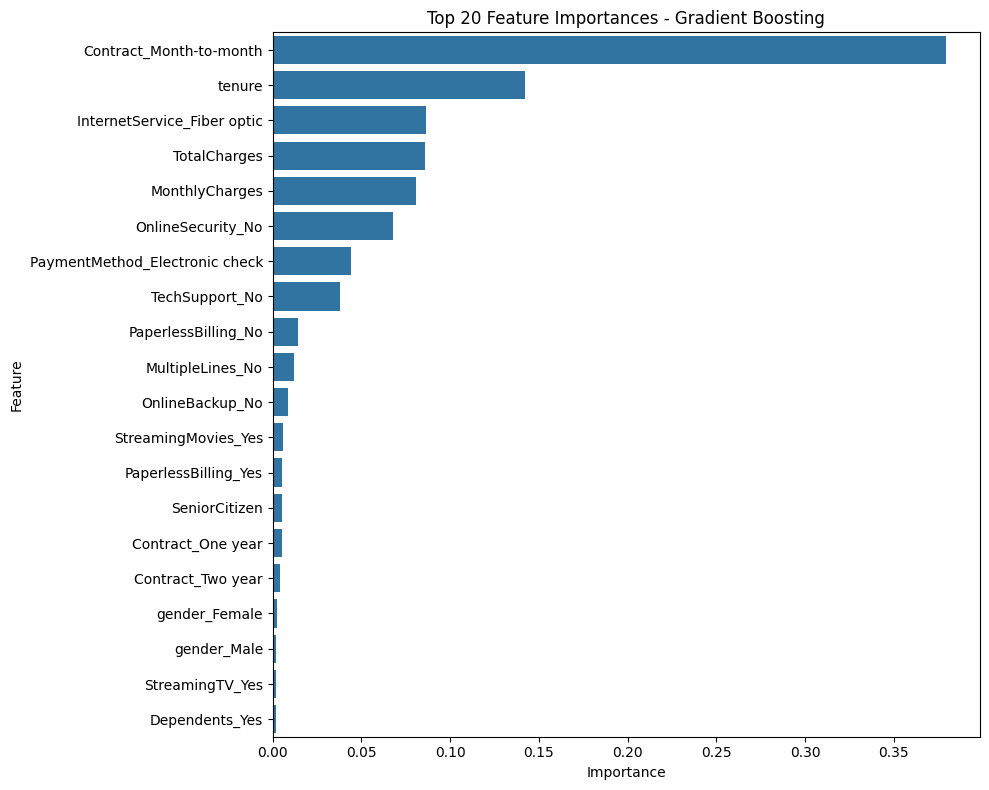

In [54]:
if hasattr(final_estimator, "feature_importances_"):
    top_features = feature_importance_df.head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=top_features, x="importance", y="feature")
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("../reports/figures/feature_importance.png", dpi=300)
    plt.show()

## 13. Modeling Summary

本Notebookでは、Telco Customer Churnデータセットを用いて、顧客解約を予測する機械学習モデルを構築した。

### 実施内容

1. `TotalCharges` を数値型に変換し、欠損値を0で補完した
2. `customerID` を削除した
3. 目的変数 `Churn` を `No=0`, `Yes=1` に変換した
4. 数値変数には標準化、カテゴリ変数にはOne-Hot Encodingを適用した
5. Logistic Regression, Random Forest, Gradient Boosting の3モデルを比較した
6. Accuracy, Precision, Recall, F1-score, ROC-AUCで性能を評価した
7. ROC-AUCが最も高いモデルを最終モデルとして選択した
8. 最終モデルを `models/churn_model.pkl` として保存した

### 評価方針

解約予測では、単純なAccuracyだけでなく、実際に解約する顧客をどれだけ見逃さず検出できるかが重要である。
そのため、RecallやF1-score、ROC-AUCも確認した。

### 今後の改善

- ハイパーパラメータチューニング
- 閾値調整によるRecall改善
- SHAPを用いた予測理由の可視化
- クラス不均衡への対応
- Streamlitアプリ化